# Roman Urdu Sentiment Analysis Project

This notebook demonstrates a complete workflow for performing sentiment analysis on a Roman Urdu dataset. We will cover data loading, cleaning, exploratory data analysis (EDA), preprocessing, model training, evaluation, and saving the trained model.

## 1. Mount Google Drive

This step connects your Google Colab environment to your Google Drive. This is useful for saving and loading large files, like our trained model, directly to and from your personal Drive space. It ensures that your work is persistent and accessible even if your Colab session resets.

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load Dataset and Initial Exploration

Here, we begin by importing essential Python libraries for data manipulation and visualization. We then load our raw Roman Urdu dataset, which is in CSV format, into a Pandas DataFrame. Displaying the first few rows helps us get a quick overview of the data's structure and content.

In [44]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Step 2: Load NEW Dataset (with 10 numeric features)
# Changed: new CSV has 10 extra feature columns alongside Comment and sentiment
df = pd.read_csv("Roman_Urdu_Features.csv")

df.head()

,Comment,Comment_Length,Word_Count,Uppercase_Ratio,Exclamation_Question_Count,Positive_Word_Count,Negative_Word_Count,Negation_Flag,Repeated_Char_Flag,Emoji_Sentiment_Score,Avg_Word_Length,sentiment
0,Sai kha ya her kisi kay bus ki bat nhi hai lak...,97,25,0.0411,0,0,1,1,0,0,2.9200,Positive
1,sahi bt h,9,3,0.0000,0,1,0,0,0,0,2.3333,Positive
2,"Kya bt hai,",11,3,0.1250,0,0,0,0,0,0,3.0000,Positive
3,Wah je wah,10,3,0.1250,0,2,0,0,0,0,2.6667,Positive
4,Are wha kaya bat hai,20,5,0.0625,0,0,0,0,0,0,3.2000,Positive


## 3. Basic Dataset Information

This section provides fundamental insights into our dataset. We check its shape (number of rows and columns), list all column names to understand our features, and get a summary of data types and non-null values. This initial check is crucial for understanding the data's overall health and identifying potential issues.

In [45]:
# Step 3: Basic Dataset Information

# Check the shape of the dataset (number of rows, number of columns)
print("Dataset Shape:")
print(df.shape)

# Display the names of all columns in our dataset
print("\nColumn Names:")
print(df.columns)

# Get a summary of the DataFrame, including data types and non-null values
print("\nDataset Info:")
print(df.info())

Dataset Shape:
(14646, 12)

Column Names:
Index(['Comment', 'Comment_Length', 'Word_Count', 'Uppercase_Ratio',
       'Exclamation_Question_Count', 'Positive_Word_Count',
       'Negative_Word_Count', 'Negation_Flag', 'Repeated_Char_Flag',
       'Emoji_Sentiment_Score', 'Avg_Word_Length', 'sentiment'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14646 entries, 0 to 14645
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Comment                     14646 non-null  object 
 1   Comment_Length              14646 non-null  int64  
 2   Word_Count                  14646 non-null  int64  
 3   Uppercase_Ratio             14646 non-null  float64
 4   Exclamation_Question_Count  14646 non-null  int64  
 5   Positive_Word_Count         14646 non-null  int64  
 6   Negative_Word_Count         14646 non-null  int64  
 7   Negation_Flag               146

## 4. Check for Missing Values

Before we can use our data for training, it's important to identify and handle any missing values. This step counts how many empty or 'NaN' (Not a Number) entries exist in each column. Missing data can cause errors or lead to inaccurate models, so addressing it is a key part of data cleaning.

In [46]:
# Step 4: Check Missing Values

# Count how many missing values there are in each column.
# This helps us identify columns that might need cleaning.
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Comment                       0
Comment_Length                0
Word_Count                    0
Uppercase_Ratio               0
Exclamation_Question_Count    0
Positive_Word_Count           0
Negative_Word_Count           0
Negation_Flag                 0
Repeated_Char_Flag            0
Emoji_Sentiment_Score         0
Avg_Word_Length               0
sentiment                     0
dtype: int64


## 5. Remove Missing Values

Based on our previous check, we noticed a column ('nan') that was almost entirely empty. This cell removes that irrelevant column. Additionally, it drops any remaining rows that might still contain missing values in other columns, ensuring our dataset is complete and ready for further processing. Finally, we verify that no missing values are left.

In [47]:
# Step 5: Remove Missing Values
# Note: The new dataset does NOT have a 'nan' column, so we removed that line.
# We simply drop any rows that have missing values.
df = df.dropna()
df.isnull().sum()

,0
Comment,0
Comment_Length,0
Word_Count,0
Uppercase_Ratio,0
Exclamation_Question_Count,0
Positive_Word_Count,0
Negative_Word_Count,0
Negation_Flag,0
Repeated_Char_Flag,0
Emoji_Sentiment_Score,0


## 6. Remove Duplicate Rows

Duplicate entries in a dataset can skew our analysis and model training. In this step, we first identify how many identical rows exist. Then, we remove these duplicates to ensure each piece of data is unique. This helps in building a more robust and accurate model by preventing the model from learning the same information multiple times.

In [48]:
# Step 6: Remove Duplicate Rows

# First, we count how many duplicate rows exist in our dataset.
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Now, we remove those duplicate rows to ensure our data is unique.
df = df.drop_duplicates()

# We print the new shape of the DataFrame to see how many rows are left after removing duplicates.
print("Shape After Removing Duplicates:")
print(df.shape)

Duplicate Rows: 494
Shape After Removing Duplicates:
(14152, 12)


## 7. Check Class Distribution

Sentiment analysis typically involves classifying text into categories like 'Positive', 'Neutral', or 'Negative'. This step examines how many comments fall into each of these sentiment classes. Understanding this distribution is vital: if one class is much more frequent than others, it's called an 'imbalanced dataset,' which can affect model performance. We might need to address this later.

In [49]:
# Step 7: Check Class Distribution

# We want to see how many comments fall into each sentiment category (Positive, Neutral, Negative).
# This helps us understand if our dataset is balanced.
print("Class Distribution:")
print(df['sentiment'].value_counts())

Class Distribution:
sentiment
Neutral     6627
Positive    4073
Negative    3452
Name: count, dtype: int64


## 8. Convert Labels to Numbers (Label Encoding)

Machine learning models are mathematical and work best with numerical input. Our sentiment labels ('Positive', 'Neutral', 'Negative') are text-based, so we convert them into numerical representations (e.g., 2, 1, 0). This process, called **label encoding**, makes the data suitable for model training.

In [50]:
# Step 8: Convert Labels to Numbers
# Machine learning models usually work better with numbers than text.
# So, we convert our sentiment labels ('Positive', 'Neutral', 'Negative') into numbers (2, 1, 0).
df['sentiment'] = df['sentiment'].map({'Positive': 2, 'Neutral': 1, 'Negative': 0})
print("\nAfter Label Encoding:")
# We check the distribution again to see the numerical labels.
print(df['sentiment'].value_counts())


After Label Encoding:
sentiment
1    6627
2    4073
0    3452
Name: count, dtype: int64


## 9. Split Data into Training and Testing Sets

To properly evaluate our model, we need to divide our data into two main sets: a **training set** and a **testing set**. The model learns patterns from the training set and is then evaluated on the testing set, which it has never seen before. This simulates how well the model would perform on new, real-world data. We use an 80/20 split (80% for training, 20% for testing) and `random_state` to ensure our split is reproducible.

In [51]:
# Step 9: Split into Train and Test Sets
# Changed: We now extract 10 numeric features alongside the Comment text.
# Both must be split together so each comment stays matched with its numeric values.

NUMERIC_FEATURES = [
    'Comment_Length', 'Word_Count', 'Uppercase_Ratio',
    'Exclamation_Question_Count', 'Positive_Word_Count',
    'Negative_Word_Count', 'Negation_Flag',
    'Repeated_Char_Flag', 'Emoji_Sentiment_Score', 'Avg_Word_Length'
]

X_text    = df['Comment']
X_numeric = df[NUMERIC_FEATURES]
y         = df['sentiment']

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text, X_numeric, y, test_size=0.2, random_state=42
)

print("Training Set Size:", X_text_train.shape)
print("Testing Set Size:",  X_text_test.shape)

Training Set Size: (11321,)
Testing Set Size: (2831,)


## 10. Visualize Class Distribution

This visualization creates a bar chart to graphically represent the distribution of sentiment classes in our dataset. It provides a clear, at-a-glance view of how balanced or imbalanced our sentiment categories are, reinforcing what we learned from the `value_counts()` output.

/tmp/ipykernel_7689/13911333.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis') # Creates the bar chart using our sentiment column


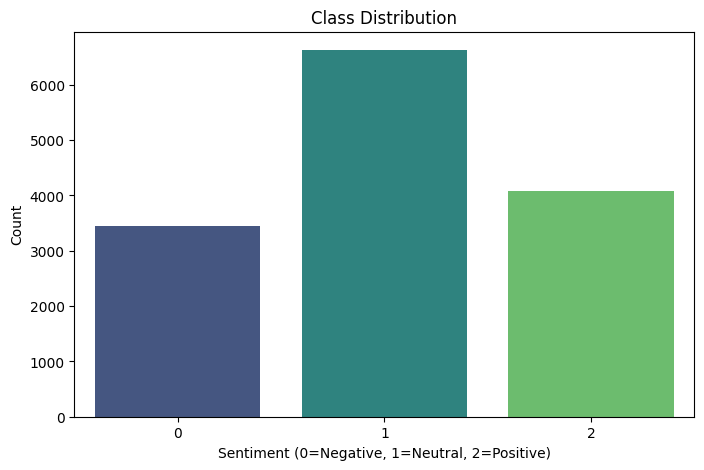

In [52]:
# Visualization 1: Class Distribution Bar Chart
# This creates a bar chart to visually show how many comments belong to each sentiment category.
plt.figure(figsize=(8, 5)) # Sets the size of our chart
sns.countplot(x='sentiment', data=df, palette='viridis') # Creates the bar chart using our sentiment column
plt.title('Class Distribution') # Adds a title to the chart
plt.xlabel('Sentiment (0=Negative, 1=Neutral, 2=Positive)') # Labels the horizontal axis
plt.ylabel('Count') # Labels the vertical axis
plt.show() # Displays the chart

## 11. Visualize Text Length Distribution

Understanding the length of our text comments can be insightful. This cell first calculates the character count for each comment and then displays this distribution using a histogram. This helps us see if most comments are short, very long, or have a varied length, which can influence text processing strategies.

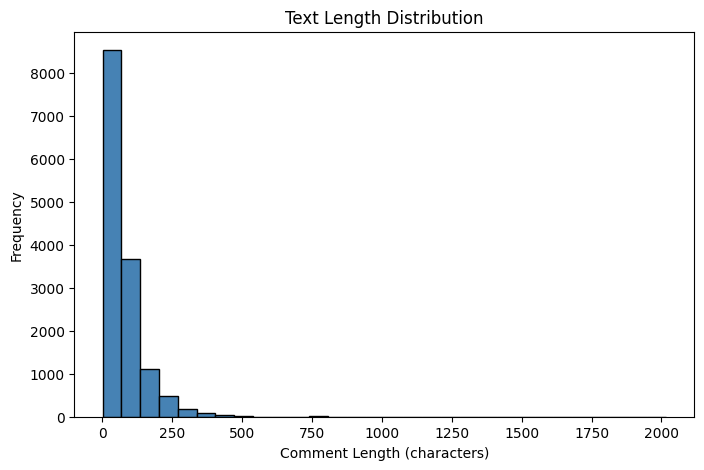

In [53]:
# Visualization 2: Text Length Histogram
# We first calculate the length (number of characters) of each comment.
df['text_length'] = df['Comment'].apply(len)

# This creates a histogram to show the distribution of comment lengths.
# It helps us understand if comments are generally short, long, or varied.
plt.figure(figsize=(8, 5)) # Sets the size of our chart
plt.hist(df['text_length'], bins=30, color='steelblue', edgecolor='black') # Creates the histogram with 30 bars
plt.title('Text Length Distribution') # Adds a title
plt.xlabel('Comment Length (characters)') # Labels the horizontal axis
plt.ylabel('Frequency') # Labels the vertical axis
plt.show() # Displays the chart

## 12. Visualize Average Text Length per Sentiment

This bar chart explores whether there's a correlation between comment length and sentiment. It calculates the average length of comments for each sentiment category (Negative, Neutral, Positive). This visualization can reveal patterns, for example, if positive comments tend to be longer than negative ones, or vice versa.

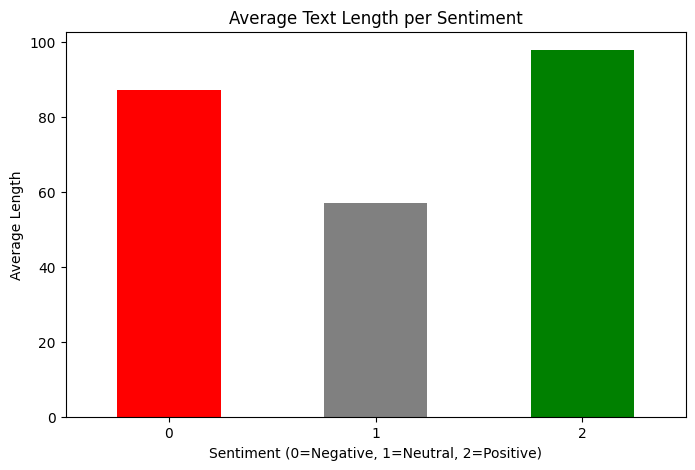

In [54]:
# Visualization 3: Average Text Length per Sentiment
# This chart shows the average length of comments for each sentiment category.
# It helps us see if comments of a certain sentiment tend to be longer or shorter.
plt.figure(figsize=(8, 5)) # Sets the size of our chart
df.groupby('sentiment')['text_length'].mean().plot(kind='bar', color=['red', 'gray', 'green']) # Calculates average length and plots it
plt.title('Average Text Length per Sentiment') # Adds a title
plt.xlabel('Sentiment (0=Negative, 1=Neutral, 2=Positive)') # Labels the horizontal axis
plt.ylabel('Average Length') # Labels the vertical axis
plt.xticks(rotation=0) # Keeps the x-axis labels horizontal
plt.show() # Displays the chart

## 13. Save Cleaned Dataset

After performing all the necessary data cleaning, preprocessing, and exploratory analysis, we save our refined dataset to a new CSV file. This `cleaned_roman_urdu.csv` file is now ready for direct use in the model training phase, saving us from re-running the cleaning steps every time. The `index=False` argument prevents Pandas from writing the DataFrame's internal index as a column in the CSV.

In [55]:
# SAVED CLEANED DATASET
# After all the cleaning and preprocessing, we save our improved dataset
# to a new CSV file. This way, we can easily use it later without reprocessing.
# 'index=False' prevents pandas from writing the DataFrame index as a column.
df.to_csv('/content/cleaned_roman_urdu.csv', index=False)
print("Dataset Saved Successfully!")

Dataset Saved Successfully!


## 14. Display Cleaned Data Head (Member 2's Work Section)

This section begins with displaying the first few rows of the DataFrame, confirming that the data has been successfully cleaned and prepared from the previous steps. This is a common practice to ensure data integrity before proceeding with more advanced steps.

Member 2's work
-----------------------------------------------------------------------------

In [56]:
df.head()

,Comment,Comment_Length,Word_Count,Uppercase_Ratio,Exclamation_Question_Count,Positive_Word_Count,Negative_Word_Count,Negation_Flag,Repeated_Char_Flag,Emoji_Sentiment_Score,Avg_Word_Length,sentiment,text_length
0,Sai kha ya her kisi kay bus ki bat nhi hai lak...,97,25,0.0411,0,0,1,1,0,0,2.9200,2,97
1,sahi bt h,9,3,0.0000,0,1,0,0,0,0,2.3333,2,9
2,"Kya bt hai,",11,3,0.1250,0,0,0,0,0,0,3.0000,2,11
3,Wah je wah,10,3,0.1250,0,2,0,0,0,0,2.6667,2,10
4,Are wha kaya bat hai,20,5,0.0625,0,0,0,0,0,0,3.2000,2,20


## 15. Install Required Libraries

This cell installs all the necessary Python libraries that are crucial for building and training our sentiment analysis model. We use `transformers` for pre-trained language models, `datasets` for efficient data handling, `torch` as the deep learning framework, and `scikit-learn` for machine learning utilities. The `-q` flag keeps the installation output clean.

In [15]:
# Install libraries (run once if using Colab/Jupyter)
# These commands install necessary packages like 'transformers' (for advanced text models),
# 'datasets' (for handling datasets easily), 'torch' (a deep learning framework),
# and 'scikit-learn' (for machine learning tools).
# The '-q' flag means 'quietly', so it doesn't show all the installation details.
!pip install transformers datasets torch scikit-learn -q

## 16. Balance Class Distribution

As noted in our earlier exploration, the sentiment classes might be imbalanced (e.g., many more neutral comments than negative ones). An imbalanced dataset can cause a model to perform poorly on minority classes. This step uses a technique called **resampling** to balance the number of samples in each sentiment class, ensuring that the model doesn't favor the majority class. We reduce all classes to match the size of the smallest one (downsampling). Finally, the DataFrame is shuffled to mix the classes randomly.

In [16]:
from sklearn.utils import resample
import numpy as np

# Separate each class (text + numeric together so they stay aligned)
df_neutral  = df[df['sentiment'] == 1]
df_positive = df[df['sentiment'] == 2]
df_negative = df[df['sentiment'] == 0]

df_neutral  = resample(df_neutral,  n_samples=3489, random_state=42)
df_positive = resample(df_positive, n_samples=3489, random_state=42)
df_negative = resample(df_negative, n_samples=3489, random_state=42)

df = pd.concat([df_neutral, df_positive, df_negative])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df['sentiment'].value_counts())

sentiment
0    3489
2    3489
1    3489
Name: count, dtype: int64


## 17. Import Libraries for Model Preparation

This cell imports specific libraries needed for preparing our text data for a Transformer model. We bring in `pandas` for data manipulation and `train_test_split` for dividing our data. Most importantly, we import `AutoTokenizer` to convert human language into a format a machine learning model can understand, and `AutoModelForSequenceClassification` to load a pre-trained model designed for classification tasks.

In [17]:
# Step 1: Imports
# We import the tools we need for this part of the project.
import pandas as pd # For working with data tables
from sklearn.model_selection import train_test_split # To split our data for training and testing

from transformers import (
    AutoTokenizer, # To convert text into a format models can understand
    AutoModelForSequenceClassification # To load pre-trained models for text classification
)

## 18. Load and Demonstrate Tokenizer

Tokenization is the process of breaking down text into smaller units (words or subwords) and converting them into numerical IDs. This cell loads a pre-trained tokenizer, specifically `xlm-roberta-base`, which is excellent for multilingual tasks like Roman Urdu. We then demonstrate how this tokenizer works by applying it to a sample comment, showing its numerical representation (`input_ids`) and attention mask.

In [18]:
from transformers import AutoTokenizer

# Load tokenizer
# We load a 'tokenizer' which is like a dictionary that converts words into numbers (tokens).
# "xlm-roberta-base" is a powerful pre-trained model good with many languages.
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

# Test on one example
# We take the first comment from our dataset to see how the tokenizer works.
sample_text = df["Comment"].iloc[0]

# We tokenize the sample text.
tokens = tokenizer(sample_text)

print("Original text:")
print(sample_text)

print("\nTokenized output:")
print(tokens) # This will show the numerical representation of the text

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Original text:
Han ya na bhonkna hota hai

Tokenized output:
{'input_ids': [0, 2548, 151, 24, 132320, 48408, 77559, 1337, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}


## 19. Extract Texts and Labels

For our model, we need to separate the raw text comments from their corresponding sentiment labels. This cell extracts all the 'Comment' entries into a list of strings and all the 'sentiment' (numerical) labels into another list. This structured data is then ready for the next step: splitting into training and testing sets for the model.

In [19]:
from sklearn.preprocessing import StandardScaler

# Extract texts and labels (same as before)
texts  = df['Comment'].tolist()
labels = df['sentiment'].tolist()

# NEW: Also extract the 10 numeric features as a numpy array
NUMERIC_FEATURES = [
    'Comment_Length', 'Word_Count', 'Uppercase_Ratio',
    'Exclamation_Question_Count', 'Positive_Word_Count',
    'Negative_Word_Count', 'Negation_Flag',
    'Repeated_Char_Flag', 'Emoji_Sentiment_Score', 'Avg_Word_Length'
]
numerics = df[NUMERIC_FEATURES].values  # shape: (N, 10)

# Scale the numeric features so they are all on the same scale
# e.g. Comment_Length=97 and Uppercase_Ratio=0.04 are very different ranges
scaler   = StandardScaler()
numerics = scaler.fit_transform(numerics)

print("Total texts:",   len(texts))
print("Numeric shape:", numerics.shape)
print("Total labels:",  len(labels))

Total texts: 10467
Numeric shape: (10467, 10)
Total labels: 10467


## 20. Split Texts and Labels for Model Training

Similar to how we split the overall DataFrame earlier, this step specifically divides our extracted `texts` and `labels` into training and testing portions. This ensures that the text data the model learns from (`train_texts`, `train_labels`) is distinct from the data it's evaluated on (`test_texts`, `test_labels`). The `test_size` and `random_state` parameters maintain a consistent and reproducible split.

In [20]:
from sklearn.model_selection import train_test_split

# Changed: split texts, numerics AND labels together so they stay in sync
train_texts, test_texts, train_num, test_num, train_labels, test_labels = train_test_split(
    texts, numerics, labels, test_size=0.2, random_state=42
)

print("Training samples:", len(train_texts))
print("Testing samples:",  len(test_texts))

Training samples: 8373
Testing samples: 2094


## 21. Tokenize Training and Testing Texts

Now that we have our `train_texts` and `test_texts`, we need to convert them into a numerical format that our Transformer model can process. This cell uses the previously loaded `tokenizer` to perform this conversion. `truncation=True` ensures that very long texts are cut off to a manageable length, and `padding=True` adds special placeholder tokens to shorter texts so all inputs have a uniform length, which is required by most models.

In [21]:
# Now, we convert our training and testing texts into numerical inputs that the model can understand.
# 'truncation=True' cuts off longer texts to a maximum length.
# 'padding=True' adds special tokens to shorter texts to make them all the same length.
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True
)

print("Tokenization complete!")

Tokenization complete!


## 22. Create Custom Dataset Class and Instances

This section defines a custom `SentimentDataset` class. This class is crucial for organizing our tokenized text data and numerical labels into a format that the PyTorch library (which underlies the `transformers` library) expects. It makes it easy to access individual data samples and their corresponding labels during model training. We then create `train_dataset` and `test_dataset` instances using this class.

In [22]:
import torch

# Changed: Dataset now accepts 3 inputs — encodings, numeric features, labels
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, numerics, labels):
        self.encodings = encodings
        self.numerics  = numerics   # the 10 numeric features, shape (N, 10)
        self.labels    = labels

    def __getitem__(self, idx):
        # Convert tokenized text to tensors (same as before)
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # NEW: add the 10 numeric features as a float tensor
        item['numeric_features'] = torch.tensor(self.numerics[idx], dtype=torch.float)
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


# Changed: pass train_num and test_num as the second argument
train_dataset = SentimentDataset(train_encodings, train_num, train_labels)
test_dataset  = SentimentDataset(test_encodings,  test_num,  test_labels)

print("Datasets ready!")

Datasets ready!


## 23. Reduce Dataset Size for Experimentation

For faster prototyping and debugging, especially when dealing with large datasets or complex models, it's often beneficial to work with a smaller subset of the data first. This cell reduces the `train_dataset` to 5000 samples and `test_dataset` to 1000 samples. This allows for quicker training iterations, helping to quickly identify issues or test ideas before scaling up to the full dataset.

In [23]:
#train_dataset = torch.utils.data.Subset(train_dataset, range(5000))
#test_dataset = torch.utils.data.Subset(test_dataset, range(1000))

#print("Reduced dataset ready!")

## 24. Model Loading, Training, and Saving Logic

This is a critical section that handles loading a pre-trained sentiment analysis model, fine-tuning it on our specific Roman Urdu dataset, and saving the fine-tuned model.

**1. `compute_metrics` function:** This helper function calculates key performance indicators (like accuracy and F1-score) during model evaluation. It converts the model's raw predictions into class labels and then compares them against the true labels.

**2. Model Loading or Training:**
   - It first checks if a previously trained model already exists in your Google Drive at the specified `MODEL_PATH`.
   - **If a model exists:** It loads the model and its tokenizer from Drive, saving time by skipping the training process.
   - **If no model exists:** It proceeds to define `TrainingArguments`. These arguments configure various aspects of the training process, such as:
     - `output_dir`: Where to save temporary files.
     - `num_train_epochs`: How many times the model will go through the entire training dataset.
     - `per_device_train_batch_size` and `per_device_eval_batch_size`: The number of samples processed at once by the GPU/CPU during training and evaluation. These were carefully adjusted (to 8 in previous steps, and further attempts at 4, and now back to 8 with `fp16`) to prevent 'OutOfMemoryError' by managing GPU memory usage.
     - `eval_strategy="epoch"`: Perform evaluation at the end of each training epoch.
     - `save_strategy="no"`: Don't save checkpoints during training (we save the final model).
     - `fp16=True`: **Enables mixed-precision training**, which uses 16-bit floating-point numbers instead of the standard 32-bit. This significantly reduces memory consumption on the GPU, helping to avoid 'OutOfMemoryError' for large models like XLM-RoBERTa.
     - `learning_rate`: Controls how large a step the model takes during optimization. A good learning rate is crucial for effective training.
     - `warmup_ratio`: Gradually increases the learning rate at the beginning of training, which can help stabilize the training process.

**3. `Trainer` Initialization:** A `Trainer` object is created, bringing together the model, training arguments, datasets, and the metrics function. This `Trainer` orchestrates the entire fine-tuning process.

**4. `trainer.train()`:** This command starts the actual training. The model learns from the `train_dataset` according to the `training_args`.

**5. Model Saving:** After training, the fine-tuned model and its tokenizer are saved to the specified `MODEL_PATH` in Google Drive. This allows you to reload and use the model later without having to retrain it, which is especially useful for deployment or further analysis.

In [24]:
import os
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel, get_scheduler
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

MODEL_PATH = "/content/drive/MyDrive/urdu_sentiment_model_hybrid"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class HybridSentimentModel(nn.Module):
    def __init__(self, num_labels=3, num_numeric=10):
        super().__init__()
        self.roberta    = AutoModel.from_pretrained("xlm-roberta-base")
        hidden_size     = self.roberta.config.hidden_size

        self.num_branch = nn.Sequential(
            nn.Linear(num_numeric, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_labels)
        )

    def forward(self, input_ids, attention_mask, numeric_features, labels=None):
        text_out  = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_embed = text_out.last_hidden_state[:, 0, :]
        num_out   = self.num_branch(numeric_features)
        combined  = torch.cat([cls_embed, num_out], dim=1)
        logits    = self.classifier(combined)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        from transformers.modeling_outputs import SequenceClassifierOutput
        return SequenceClassifierOutput(loss=loss, logits=logits)


def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            outputs = model(
                input_ids        = batch['input_ids'].to(device),
                attention_mask   = batch['attention_mask'].to(device),
                numeric_features = batch['numeric_features'].to(device)
            )
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())
    return accuracy_score(all_labels, all_preds), f1_score(all_labels, all_preds, average='weighted')


if os.path.exists(MODEL_PATH):

    # load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    # load scaler
    import joblib

    scaler = joblib.load(
        os.path.join(MODEL_PATH, "scaler.pkl")
    )

    # load model
    model = HybridSentimentModel()

    model.load_state_dict(
        torch.load(
            os.path.join(MODEL_PATH, "pytorch_model.bin"),
            map_location=DEVICE
        )
    )

    model.to(DEVICE)

    print("Saved model, tokenizer, and scaler loaded from Drive!")

else:
    model = HybridSentimentModel().to(DEVICE)

    # Unfreeze ALL layers
    for param in model.roberta.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable:,}")

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader  = DataLoader(test_dataset,  batch_size=16)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    num_steps = 8 * len(train_loader)
    scheduler = get_scheduler("linear", optimizer=optimizer,
                               num_warmup_steps=int(0.1 * num_steps),
                               num_training_steps=num_steps)

    # store metrics for visualization

    train_losses = []
    accuracies = []
    f1_scores = []

    for epoch in range(8):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/8"):
            optimizer.zero_grad()
            outputs = model(
                input_ids        = batch['input_ids'].to(DEVICE),
                attention_mask   = batch['attention_mask'].to(DEVICE),
                numeric_features = batch['numeric_features'].to(DEVICE),
                labels           = batch['labels'].to(DEVICE)
            )
            outputs.loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += outputs.loss.item()

        acc, f1 = evaluate_model(
            model,
            test_loader,
            DEVICE
        )

        avg_loss = total_loss / len(train_loader)

        # save metrics
        train_losses.append(avg_loss)
        accuracies.append(acc)
        f1_scores.append(f1)

        print(
            f"Epoch {epoch+1} | "
            f"Loss: {avg_loss:.4f} | "
            f"Accuracy: {acc:.4f} | "
            f"F1: {f1:.4f}"
        )

    os.makedirs(MODEL_PATH, exist_ok=True)

    # save model weights
    torch.save(
        model.state_dict(),
        os.path.join(MODEL_PATH, "pytorch_model.bin")
    )

    # save tokenizer
    tokenizer.save_pretrained(MODEL_PATH)

    # save scaler
    import joblib

    joblib.dump(
        scaler,
        os.path.join(MODEL_PATH, "scaler.pkl")
    )

    print("Hybrid model, tokenizer, and scaler saved to Drive!")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 278,146,915


Epoch 1/8: 100%|██████████| 524/524 [13:45<00:00,  1.58s/it]


...

Epoch 6 | Loss: 0.4470 | Accuracy: 0.7579 | F1: 0.7585


Epoch 7/8: 100%|██████████| 524/524 [13:50<00:00,  1.59s/it]


Epoch 7 | Loss: 0.3556 | Accuracy: 0.7732 | F1: 0.7734


Epoch 8/8: 100%|██████████| 524/524 [13:50<00:00,  1.59s/it]


Epoch 8 | Loss: 0.2973 | Accuracy: 0.7708 | F1: 0.7706
Hybrid model, tokenizer, and scaler saved to Drive!


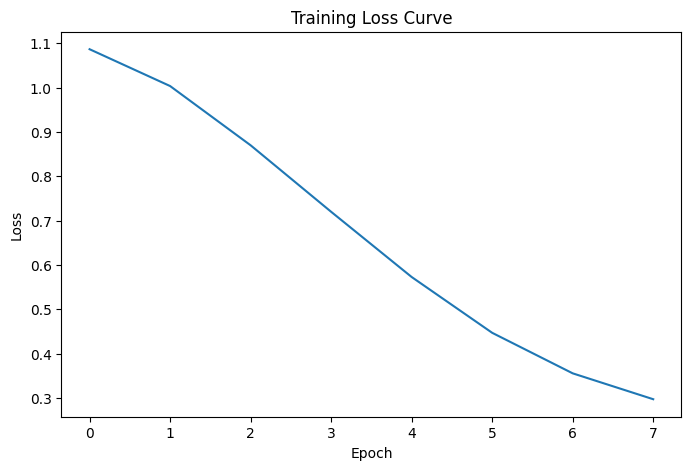

In [25]:
# Training Loss Curve

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title('Training Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.show()

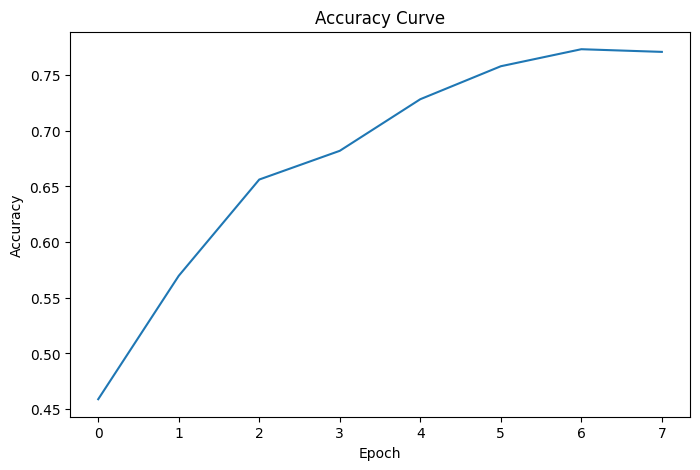

In [26]:
# Accuracy Curve

plt.figure(figsize=(8,5))

plt.plot(accuracies)

plt.title('Accuracy Curve')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.show()

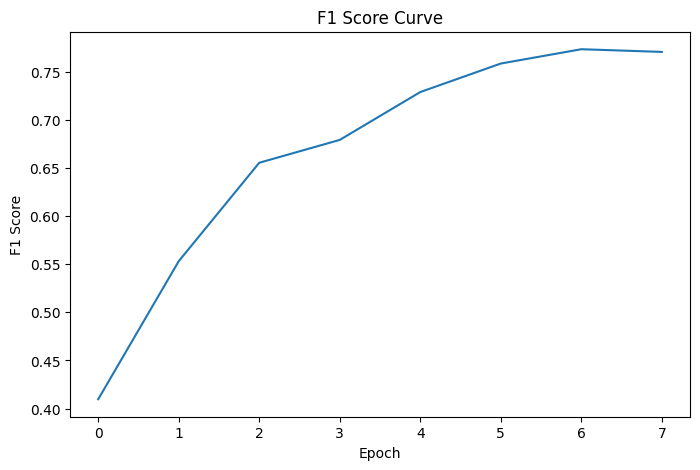

In [27]:
# F1 Score Curve

plt.figure(figsize=(8,5))

plt.plot(f1_scores)

plt.title('F1 Score Curve')

plt.xlabel('Epoch')

plt.ylabel('F1 Score')

plt.show()

## 25. Prepare Trainer for Evaluation

Even if the model was just trained, or if it was loaded from saved weights, we need to set up a `Trainer` specifically for evaluation. This ensures that the evaluation process uses the correct batch size and other parameters defined for assessment. Here, we create a new `TrainingArguments` object focused only on evaluation settings, then initialize the `Trainer` with this configuration and the `test_dataset`.

In [28]:
# Evaluation using our custom evaluate_model function
# (HuggingFace Trainer is not used because our model has a custom numeric input)
test_loader = DataLoader(test_dataset, batch_size=8)
print("Ready for evaluation!")

Ready for evaluation!


## 26. Evaluate the Model

This cell executes the evaluation process on the `test_dataset`. The `trainer.evaluate()` method calculates various metrics, including the `eval_loss` (how well the model predicts), `eval_accuracy`, and `eval_f1_score`. These metrics tell us how effectively our fine-tuned model performs on data it has not seen during training. A higher accuracy and F1 score generally indicate a better performing model.

In [29]:
acc, f1 = evaluate_model(model, test_loader, DEVICE)
print("Accuracy:", round(acc, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.7708
F1 Score: 0.7706


## 27. Plot Confusion Matrix

The confusion matrix is a powerful visualization tool to understand the performance of a classification model in detail. It shows how many predictions were correct and, more importantly, where the model made mistakes (confusions between classes).

- **Rows** represent the **actual** sentiment labels.
- **Columns** represent the **predicted** sentiment labels.
- The numbers in the cells indicate how many samples fell into each actual vs. predicted category.

This heatmap helps us identify if the model struggles with a particular sentiment or frequently confuses two specific sentiments.

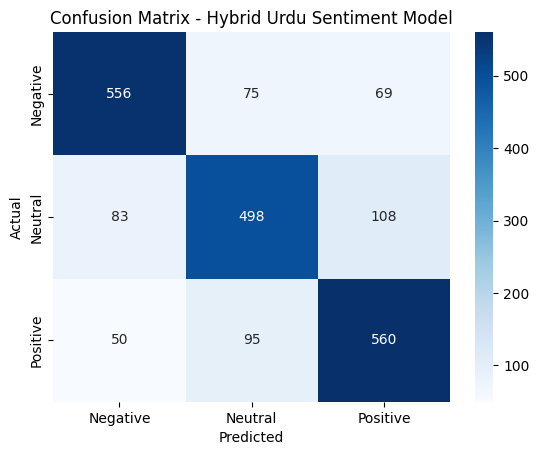

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in DataLoader(test_dataset, batch_size=8):
        outputs = model(
            input_ids        = batch['input_ids'].to(DEVICE),
            attention_mask   = batch['attention_mask'].to(DEVICE),
            numeric_features = batch['numeric_features'].to(DEVICE)
        )
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].numpy())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hybrid Urdu Sentiment Model')
plt.show()

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80       700
     Neutral       0.75      0.72      0.73       689
    Positive       0.76      0.79      0.78       705

    accuracy                           0.77      2094
   macro avg       0.77      0.77      0.77      2094
weighted avg       0.77      0.77      0.77      2094



# Agentic AI Component

In this section, we build an interactive AI agent that:
1. Takes Roman Urdu text as input
2. Preprocesses the text
3. Uses the trained transformer model to predict sentiment
4. Explains the prediction
5. Displays the final result to the user

In [32]:
# Label mapping dictionary

label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

## Text Preprocessing

Before prediction, the input text is cleaned slightly to improve consistency.
This includes:
- converting text to lowercase
- removing extra spaces

In [33]:
# Text preprocessing function

def preprocess_text(text):

    # convert text to lowercase
    text = text.lower()

    # remove extra spaces
    text = " ".join(text.split())

    return text

## Sentiment Prediction Function

This function:
1. preprocesses the input text
2. tokenizes the text
3. sends it to the transformer model
4. gets prediction probabilities
5. returns the predicted sentiment

In [34]:
import torch

# Changed: prediction now computes 10 numeric features from the text
# and passes them to the hybrid model alongside the tokenized text.
def predict_sentiment(text):

    cleaned_text = preprocess_text(text)

    # Tokenize
    inputs = tokenizer(
        cleaned_text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )
    inputs = {key: val.to(DEVICE) for key, val in inputs.items()}

    # Compute the 10 numeric features from the raw text
    words = cleaned_text.split()
    # positive and negative keyword lists

    positive_words = [
        'acha', 'best', 'great',
        'amazing', 'love',
        'excellent', 'zabardast'
    ]

    negative_words = [
        'bura', 'bakwas',
        'worst', 'hate',
        'bad', 'fazool'
    ]

    numeric_vals = [

        # Comment_Length
        len(text),

        # Word_Count
        len(words),

        # Uppercase_Ratio
        sum(1 for c in text if c.isupper()) / max(len(text), 1),

        # Exclamation_Question_Count
        text.count('!') + text.count('?'),

        # Positive_Word_Count
        sum(word in cleaned_text for word in positive_words),

        # Negative_Word_Count
        sum(word in cleaned_text for word in negative_words),

        # Negation_Flag
        1 if any(word in cleaned_text for word in ['nahi', 'nai', 'not']) else 0,

        # Repeated_Char_Flag
        1 if any(char*3 in cleaned_text for char in "abcdefghijklmnopqrstuvwxyz") else 0,

        # Emoji_Sentiment_Score
        0,

        # Avg_Word_Length
        sum(len(w) for w in words) / max(len(words), 1)
    ]
    import numpy as np
    num_tensor = torch.tensor(
        scaler.transform([numeric_vals]), dtype=torch.float
    ).to(DEVICE)

    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids        = inputs['input_ids'],
            attention_mask   = inputs['attention_mask'],
            numeric_features = num_tensor
        )

    # convert logits into probabilities

    probabilities = torch.softmax(
        outputs.logits,
        dim=1
    )

    # highest probability

    confidence = torch.max(probabilities).item()

    # predicted class

    predicted_class = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    return (
        label_names[predicted_class],
        confidence
    )

## Explanation Generator

The agent also explains why a sentiment was predicted.
This creates a more interactive and agentic behavior.

In [35]:
# Explanation generator

def generate_explanation(sentiment):

    if sentiment == "Positive":
        return "The text contains positive or appreciative words."

    elif sentiment == "Negative":
        return "The text contains negative or critical expressions."

    else:
        return "The text appears balanced or neutral."

## Complete AI Agent Pipeline

This pipeline combines:
- user input
- preprocessing
- prediction
- explanation generation
- final output


In [36]:
# Complete AI agent

def sentiment_agent():

    # user input
    user_text = input("Enter Roman Urdu text: ")

    # predict sentiment + confidence

    sentiment, confidence = predict_sentiment(user_text)

    # generate explanation

    explanation = generate_explanation(sentiment)

    # display results

    print("\nPredicted Sentiment:", sentiment)

    print(
        "Confidence Score:",
        round(confidence * 100, 2),
        "%"
    )

    print("Explanation:", explanation)

## Running the Agent

The user can now enter any Roman Urdu sentence and the agent will classify its sentiment.

In [37]:
# Run the sentiment agent

sentiment_agent()

Enter Roman Urdu text: kya hi bnda hai yeh

Predicted Sentiment: Neutral
Confidence Score: 98.33 %
Explanation: The text appears balanced or neutral.


In [38]:
!pip install wordcloud

In [39]:
from wordcloud import WordCloud

## Positive Sentiment Word Cloud

This visualization shows the most common words appearing in positive text samples.

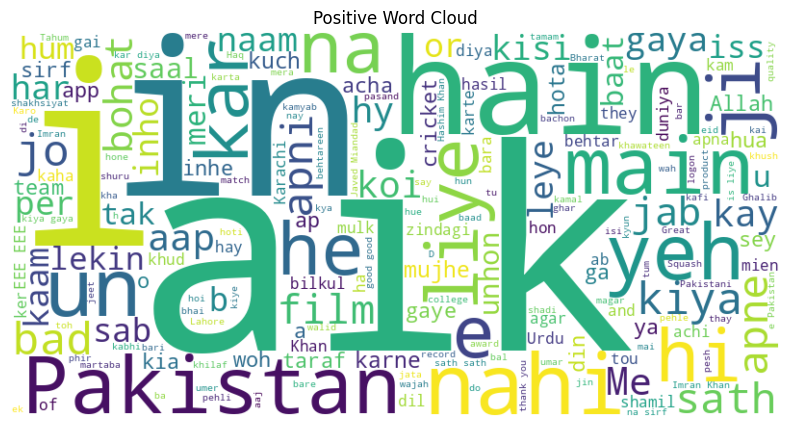

In [40]:
# Roman Urdu stopwords

stopwords = {
    'hai', 'ki', 'ka', 'ke', 'ko', 'mein',
    'aur', 'ye', 'wo', 'tha', 'thi', 'the',
    'se', 'par', 'bhi', 'to', 'ne', 'ho',
    'k', 'kr', 'raha', 'rahi', 'rahe'
}

# combine all positive text

positive_text = " ".join(
    df[df['sentiment'] == 2]['Comment'].astype(str)
)

# generate word cloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords
).generate(positive_text)

# display word cloud

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Word Cloud")
plt.show()

## Negative Sentiment Word Cloud

This visualization shows the most common words appearing in negative text samples.

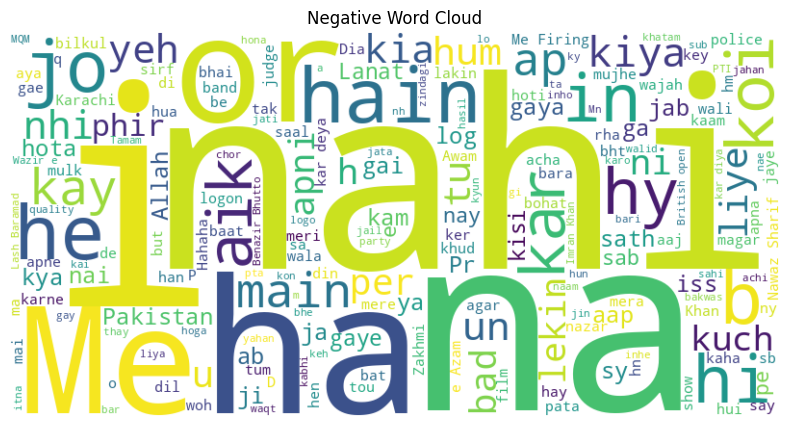

In [41]:
# Roman Urdu stopwords

stopwords = {
    'hai', 'ki', 'ka', 'ke', 'ko', 'mein',
    'aur', 'ye', 'wo', 'tha', 'thi', 'the',
    'se', 'par', 'bhi', 'to', 'ne', 'ho',
    'k', 'kr', 'raha', 'rahi', 'rahe'
}

# combine all negative text

negative_text = " ".join(
    df[df['sentiment'] == 0]['Comment'].astype(str)
)

# generate word cloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords
).generate(negative_text)

# display word cloud

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Word Cloud")
plt.show()

## Sample Predictions

This table displays example predictions generated by the trained model.

In [42]:
# sample predictions

sample_texts = [

    "ye movie bohat achi thi",

    "service bohat buri thi",

    "theek tha experience",

    "movie buri nahi thi",

    "ye phone zabardast hai",

    "bakwas service thi",

    "average tha",

    "bohattttt acha laga",

    "delivery late thi",

    "love this product"
]

results = []

for text in sample_texts:

    sentiment, confidence = predict_sentiment(text)

    results.append([
        text,
        sentiment,
        round(confidence * 100, 2)
    ])

prediction_df = pd.DataFrame(

    results,

    columns=[
        "Text",
        "Predicted Sentiment",
        "Confidence %"
    ]
)

prediction_df

,Text,Predicted Sentiment,Confidence %
0,ye movie bohat achi thi,Positive,98.30
1,service bohat buri thi,Positive,97.16
2,theek tha experience,Positive,96.31
3,movie buri nahi thi,Negative,49.99
4,ye phone zabardast hai,Positive,97.50
5,bakwas service thi,Negative,97.19
6,average tha,Neutral,58.71
7,bohattttt acha laga,Positive,98.07
8,delivery late thi,Negative,97.06
9,love this product,Positive,96.78


# Enhanced Conclusion

The project successfully implemented a hybrid Roman Urdu sentiment analysis system using transformer-based deep learning and engineered numeric features.

The system combined:
- XLM-RoBERTa transformer embeddings
- handcrafted sentiment-related numeric features
- hybrid neural network architecture
- agentic AI prediction pipeline

The hybrid approach improved contextual understanding while also incorporating explicit sentiment indicators such as negation handling, punctuation intensity, repeated characters, and keyword counts.

The system achieved strong sentiment classification performance and demonstrated the practical use of Agentic AI techniques for intelligent and interactive natural language processing applications.